## Airline Customer Satisfaction Analysis

This exploratory analysis is based on a Kaggle dataset about customer satisfaction with Invistico Airlines.

The purpose of this report is to present insights for a **fictional product** team by analyzing the customer experience, identifying service improvement opportunities, and proposing priorities for action.

The data is stored in a CSV file and loaded locally into a dataframe, which is a data structure provided by the Pandas library. The dataset contains 129,880 records.

The columns `satisfaction`, `Gender`, `Customer Type`, `Type of Travel`, and `Class` are categorical variables.

The columns that will be referred to as  `Services` throughout the analysis are: `Seat comfort`, `Departure/Arrival time convenient`, `Food and drink`, `Online support`, `Ease of Online booking`, `On-board service`, `Leg room service`, `Baggage handling`, `Checkin service`, and `Cleanliness`. These are numerical columns that contain integer values from 0 to 5, representing the customer’s satisfaction level with each specific service, where 0 means not satisfied at all and 5 means very satisfied.

The dataset also includes the numerical columns `Age`, `Flight Distance`, `Departure Delay in Minutes`, and `Arrival Delay in Minutes`.

To begin the analysis, the following libraries were imported:


In [9]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [220]:
data = pd.read_csv("C:/Users/maalr/Downloads/Invistico_Airline/Invistico_Airline.csv") 
data.head()

##Tamaño del dataframe 
#data.shape
## Conocer las columnas y los tipos de datos del dataset 
#data.columns
#data.dtypes
#data.describe().loc[["mean", "min", "max"]]
## Revisar los valores nulos 
#data.isnull().sum() ##suma la cantidad de valores nulos por columna

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,...,4,2,2,0,2,4,2,5,0,0.0


### Satisfaction Distribution

Dissatisfied:  45.27 %
Satisfied:  54.73 %


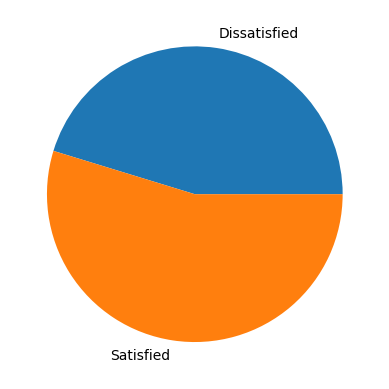

In [340]:
dissatisfied_cx = data[data['satisfaction'] == "dissatisfied"]
dis_perc = dissatisfied_cx.shape[0]/total_rows*100
print("Dissatisfied: ", round(dis_perc, 2),"%")

satisfied_cx = data[data['satisfaction'] == "satisfied"]
sat_perc = satisfied_cx.shape[0]/total_rows*100
print("Satisfied: ", round(sat_perc, 2),"%")

classes = np.array([dis_perc, sat_perc])
class_labels = ["Dissatisfied","Satisfied"]
plt.pie(classes, labels= class_labels)
plt.show() 

#### Insight 1: 

45.27% of the surveyed customers expressed dissatisfaction with the service provided by Invistico Airline.

### Dissatisfied customer profile  

In this section, only dissatisfied customers are segmented. The analysis focuses on the type of travel they made, the class they traveled in, and whether they were loyal or disloyal customers.

Class
Business    30.73
Eco         60.10
Eco Plus     9.17
dtype: float64


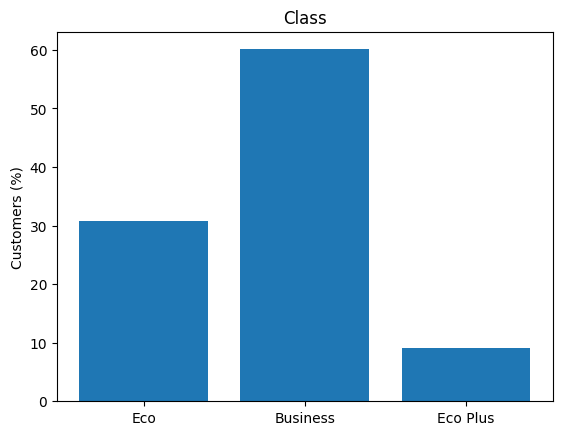

Type of Travel
Business travel    63.51
Personal Travel    36.49
dtype: float64


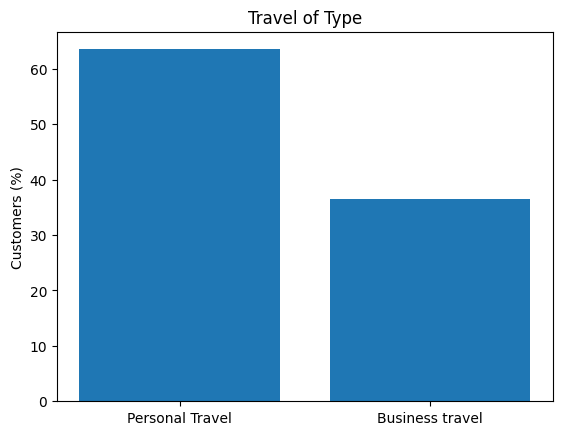

Customer Type
Loyal Customer       69.25
disloyal Customer    30.75
dtype: float64


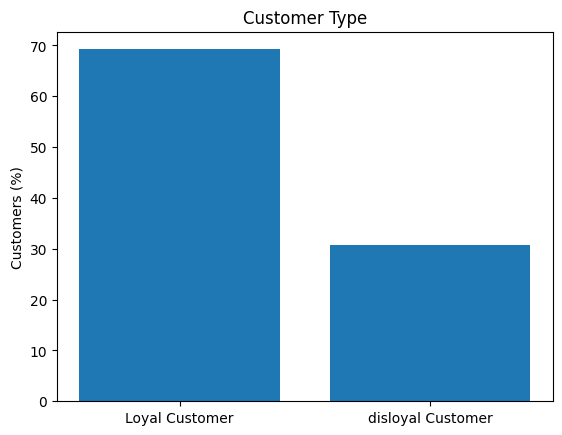

In [253]:
total_dis_cx = dissatisfied_cx.shape[0]

dis_class = dissatisfied_cx.groupby('Class').size()/total_dis_cx*100
print(round(dis_class, 2))

plt.title('Class')
plt.ylabel("Customers (%)")
plt.bar(data['Class'].unique(), dis_class)
plt.show()

dis_type_travel = dissatisfied_cx.groupby('Type of Travel').size()/total_dis_cx*100
print(round(dis_type_travel, 2))

plt.title('Travel of Type')
plt.ylabel("Customers (%)")
plt.bar(data['Type of Travel'].unique(), dis_type_travel)
plt.show()

##dis_cx_type is a filter dataframe from data that only contains 
dis_cx_type = dissatisfied_cx.groupby('Customer Type').size()/total_dis_cx*100
print(round(dis_cx_type,2))

plt.title('Customer Type')
plt.ylabel("Customers (%)")
plt.bar(data['Customer Type'].unique(), dis_cx_type)
plt.show()

#### Insight 2: 

Dissatisfied customers are typically loyal customers who travel for personal reasons and choose Business Class.

### Comparison of services among satisfied and dissatisfied customers

In this section, an average satisfaction score per service was calculated.

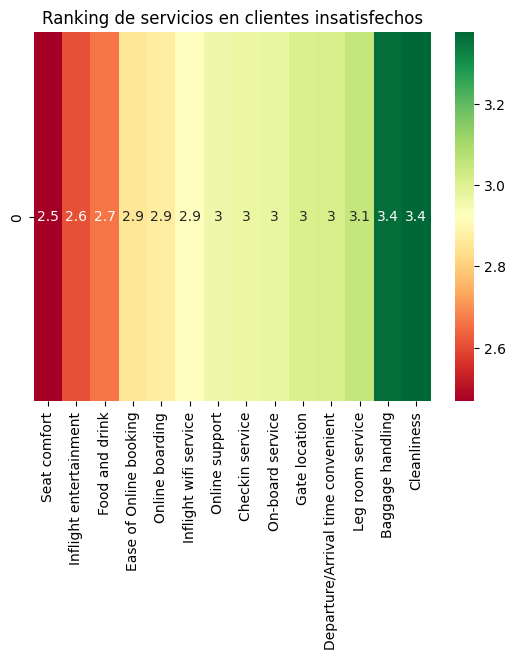

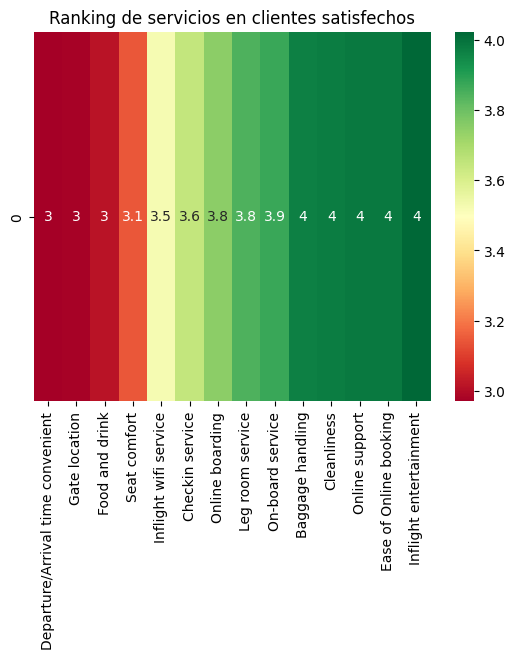

In [231]:
services = ['Seat comfort',
       'Departure/Arrival time convenient', 'Food and drink', 'Gate location',
       'Inflight wifi service', 'Inflight entertainment', 'Online support',
       'Ease of Online booking', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding']

rate_services_dis = dissatisfied_cx[services].mean().to_frame().T
rate_services_sat = satisfied_cx[services].mean().to_frame().T

ordered_services_dis = rate_services_dis.sort_values(by=0, axis=1)
ordered_services_sat = rate_services_sat.sort_values(by=0, axis=1)

plt.title('Ranking de servicios en clientes insatisfechos')
sns.heatmap(ordered_services_dis, annot=True, cmap="RdYlGn")
plt.show()

plt.title('Ranking de servicios en clientes satisfechos')
sns.heatmap(ordered_services_sat, annot=True, cmap="RdYlGn")
plt.show()

#### Insight 3:

The top three lowest-rated services among dissatisfied customers are:

1. seat comfort, 
2. inflight entertainment and 
3. food and drink.

### Satisfaction by Class

Each class category was segmented by satisfaction level to determine which class had the highest number of dissatisfied customers.

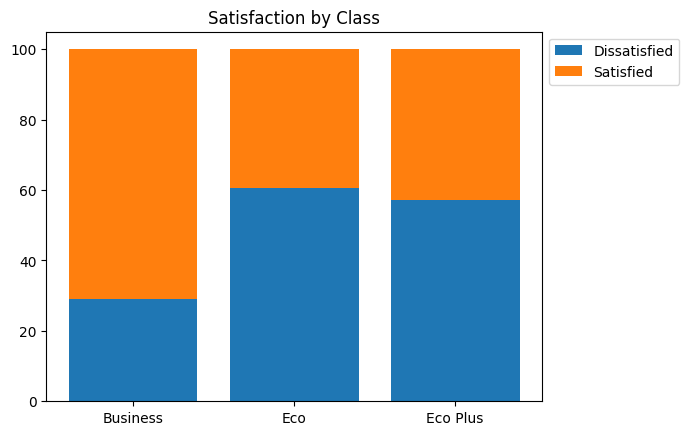

Class,Business,Eco,Eco Plus
satisfaction,,,
dissatisfied,29.062098,60.601279,57.294655
satisfied,70.937902,39.398721,42.705345


In [255]:
sat_per_class = data.groupby(['satisfaction','Class']).size().unstack()

perc_sat_p_class = sat_per_class.div(sat_per_class.sum(axis=0), axis=1) * 100

categories_class = perc_sat_p_class.columns.to_list()

plt.title('Satisfaction by Class')
plt.bar(categories_class, perc_sat_p_class.loc['dissatisfied'], label='Dissatisfied')
plt.bar(categories_class, perc_sat_p_class.loc['satisfied'], bottom= perc_sat_p_class.loc['dissatisfied'], label='Satisfied' )
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), ncol=1)
plt.show()

perc_sat_p_class.head()

#### Insight 4:

The **Economy Class** has the highest number of dissatisfied customers.

### Distribution of average satisfaction 

In this section, a new column called `Service Score` was created which contains the average service rating per customer.

- Best Score:  5.0 
- Worst Score:  1.0714285714285714 
- Percentil 75:  3.7857142857142856 
- Percentil 25:  2.857142857142857


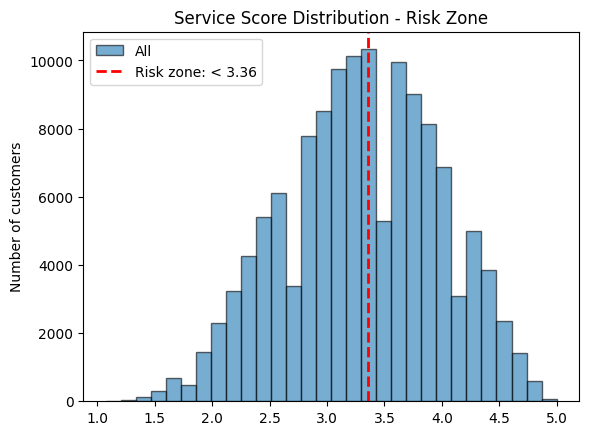

In [296]:
data["service score"] = data[services].mean(axis=1)

best_score = data["service score"].max()
worst_score = data["service score"].min()
percentil_75 = data["service score"].quantile(0.75)
percentil_25 = data["service score"].quantile(0.25)

print("- Best Score: ", best_score, "\n- Worst Score: ", worst_score, "\n- Percentil 75: ", percentil_75, "\n- Percentil 25: ", percentil_25)

service_score = data.groupby('satisfaction')['service score'].quantile(0.75)
threshold_dissatisfied = service_score['dissatisfied']

plt.hist(data['service score'], bins=30, alpha=0.6, label='All', edgecolor='black')
plt.axvline(threshold_dissatisfied, color='red', linestyle='--', linewidth=2, label=f'Risk zone: < {threshold_dissatisfied:.2f}')
plt.ylabel('Number of customers')
plt.title('Service Score Distribution - Risk Zone')
plt.legend()
plt.show()

#### Insight 5: 

Most customers give a score between 3.0 and 3.5, indicating that they perceive the airline’s overall service as acceptable.

Given the unusual distribution pattern, where three valleys can be observed, a deeper analysis was conducted to identify what may be causing these valleys. The distribution of the average service score was reviewed across the following groups:

1. Men and women
2. Travel classes: Business, Economy Plus, and Economy
3. Customer types: loyal and regular customers
4. Satisfied and dissatisfied customers
 

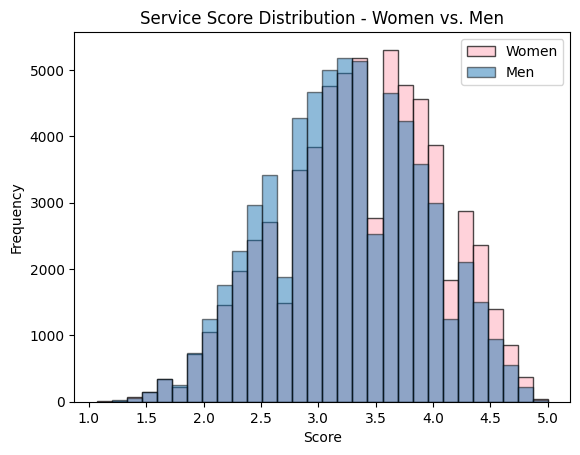

In [260]:
women_services = data[data["Gender"] == "Female"]['service score']
men_services = data[data["Gender"] == "Male"]['service score']
#women_services.head()

plt.hist(women_services, bins=30, color='pink', edgecolor='black', label='Women', alpha=0.7)
plt.hist(men_services, bins=30, edgecolor='black', alpha=0.5, label='Men')

plt.xlabel("Score")
plt.ylabel("Customers")
plt.title("Service Score Distribution - Women vs. Men")
plt.legend()

plt.show()

The same pattern observed previously is also present here, and women tend to give higher scores than men.

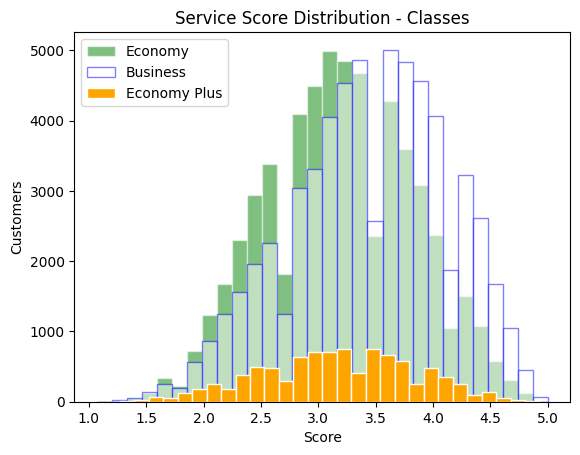

In [265]:
eco_services = data[data["Class"] == "Eco"]['service score']
business_services = data[data["Class"] == "Business"]['service score']
ecoP_services = data[data["Class"] == "Eco Plus"]['service score']

plt.hist(eco_services, bins=30, color='green', edgecolor='white', alpha=0.5, label='Economy')
plt.hist(business_services, bins=30,color='white', edgecolor='blue', alpha=0.5, label='Business')
plt.hist(ecoP_services, bins=30,color='orange', edgecolor='white', label='Economy Plus')

plt.xlabel("Score")
plt.ylabel("Customers")
plt.title("Service Score Distribution - Classes")
plt.legend()

plt.show()

The same pattern observed previously is also present here, and **Business Class** tend to give higher scores than **Economy Class**.

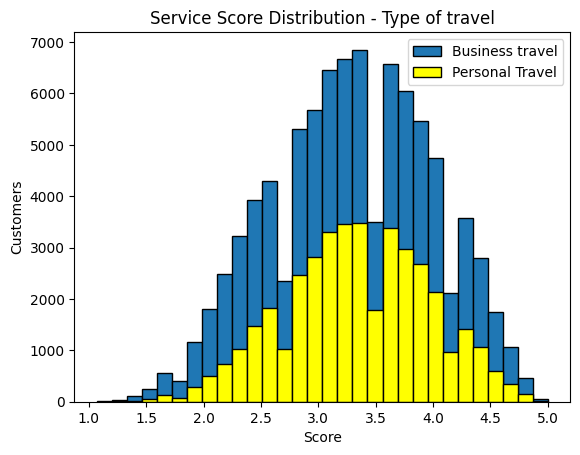

In [263]:
personal_services = data[data["Type of Travel"] == "Personal Travel"]['service score']
businessT_services = data[data["Type of Travel"] == "Business travel"]['service score']

plt.hist(businessT_services, bins=30, edgecolor='black', label='Business travel')
plt.hist(personal_services, bins=30, color='yellow', edgecolor='black', label='Personal Travel')

plt.xlabel("Score")
plt.ylabel("Customers")
plt.title("Service Score Distribution - Type of travel")
plt.legend()

plt.show()

The same pattern observed previously is also present here.

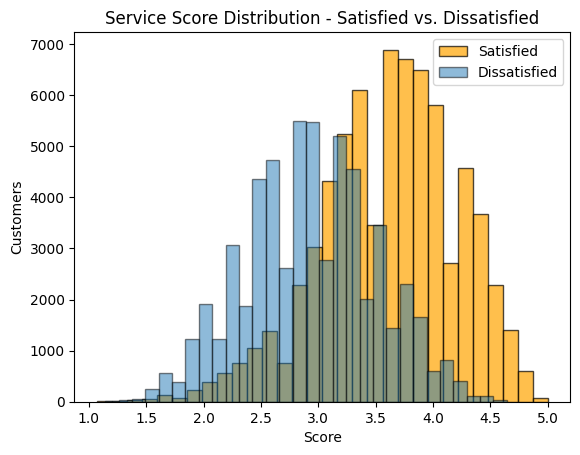

In [268]:
satisfaction_services = data[data["satisfaction"] == "satisfied"]['service score']
dissac_services = data[data["satisfaction"] == "dissatisfied"]['service score']

plt.hist(satisfaction_services, bins=30, color='orange', edgecolor='black', label='Satisfied', alpha=0.7)
plt.hist(dissac_services, bins=30, edgecolor='black', alpha=0.5, label='Dissatisfied')

plt.xlabel("Score")
plt.ylabel("Customers")
plt.title("Service Score Distribution - Satisfied vs. Dissatisfied")
plt.legend()

plt.show()

The same pattern observed previously is also present here.

#### Conclusion

Based on the previous analysis, it is not possible to determine the cause of the distribution shape, since the groups analyzed show similar patterns. The valleys may simply be due to an insufficient number of records within those rating ranges. At least with the available columns, no additional conclusion can be drawn.

### Age and Service Score (Demographic pattern)

How different ages rated the services.

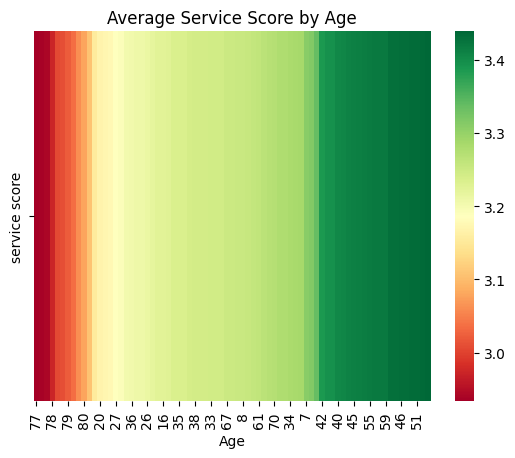

In [270]:
heatmap_data = data.groupby("Age")[["service score"]].mean().T
heatmap_data = heatmap_data.sort_values(by='service score', axis=1)
sns.heatmap(heatmap_data,annot=False,cmap="RdYlGn")

plt.title("Average Service Score by Age")
plt.xlabel("Age")
plt.show()

#### Insight 6: 

Customers older than 77 gave the lowest ratings, followed by customers aged 16 and 36. In contrast, customers between 33 and 70 years old tended to give better scores.

### Looking for Critical Segment

To provide actionable insights that help the product team prioritize improvements for the critical segment, a new dataframe was created by grouping the data by age, travel type, and class. Additionally, a new column called `age group` was added to the `dissatisfied_cx` dataframe, assigning each record to a specific age group category.

In [307]:
bins = [0, 20, 30,40, 50, 60, 100]
labels = ["<20", "20-30", "30-40", "40-50", "50-60", "+60"]
dissatisfied_cx["age group"] = pd.cut(dissatisfied_cx["Age"], bins=bins,labels=labels, right=False)

In [311]:
d = dissatisfied_cx.groupby(['Gender', 'Type of Travel', 'Class', 'age group']).size().unstack()
d_p = d.div(d.sum(axis=0), axis=1) * 100
pd.set_option("display.max_rows", None)
d_p

age group                              <20      20-30      30-40      40-50  \
Gender Type of Travel  Class                                                  
Female Business travel Business   5.515345  13.653568  19.060235  18.050222   
                       Eco       11.189925  25.407749  15.405595  13.884786   
                       Eco Plus   2.156920   3.282637   3.545547   2.520926   
       Personal Travel Business   0.825130   0.199573   0.249357   0.344658   
                       Eco        7.990735   2.917900   3.381906   4.431315   
                       Eco Plus   1.143602   0.357856   0.397413   0.630231   
Male   Business travel Business   5.211349  12.118918  19.410894  16.730675   
                       Eco       11.059641  21.120363  13.652303  13.540128   
                       Eco Plus   1.404169   1.899388   2.672797   2.166420   
       Personal Travel Business   3.372901   1.245613   1.597444   1.733136   
                       Eco       44.499131  15.608010  17.821242  22.924668   
                       Eco Plus   5.631152   2.188425   2.805268   3.042836   

age group                            50-60        +60  
Gender Type of Travel  Class                           
Female Business travel Business  14.185552  11.208653  
                       Eco       12.457744   8.151748  
                       Eco Plus   2.629273   2.586612  
       Personal Travel Business   0.550895   0.705440  
                       Eco        5.671717   7.226838  
                       Eco Plus   0.838863   1.113027  
Male   Business travel Business  14.260674  10.848095  
                       Eco       11.668962   7.320897  
                       Eco Plus   2.216101   2.382819  
       Personal Travel Business   2.291223   3.307728  
                       Eco       29.285088  39.818153  
                       Eco Plus   3.943909   5.329989

#### Insight 7: 

A critical segment identified in the analysis is men under 20 years old who travel for personal reasons in Economy Class. Sí, tiene varios errores de redacción. Based on the scores given by the critical segment, the services were ranked to identify the five lowest-rated services, which are shown below. **These services should be the priority for product team.**

In [341]:
segmento_critico = dissatisfied_cx[
                        (dissatisfied_cx['Type of Travel'] == 'Personal Travel') & 
                       (dissatisfied_cx['Class'] == 'Eco') & 
                       (dissatisfied_cx['age group'] == '<20') &
                        (dissatisfied_cx['Gender'] == 'Male')
]

rate_services_critical_seg = segmento_critico[services].mean()

ordered_services_critical_seg = rate_services_critical_seg.sort_values()
print("Top 5 worst services ranked")
print("----------------------------")
ordered_services_critical_seg.head()

Top 5 worst services ranked
----------------------------


Food and drink            2.385817
Inflight entertainment    2.406636
Seat comfort              2.418022
Gate location             2.945023
Online support            2.963565
dtype: float64